In [1]:
PROJ_NAME = "dilithium_poly_decompose_ttest"
LABEL = "param_large_init_onlya2b_1lt4"
OFFSET = 0

In [2]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [3]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32,
                                      output_len=0, offset=OFFSET)

In [4]:
trace_collector.init_target(force=False)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [5]:
trace_collector.default_setup(40E6, 12, 5000)

In [ ]:
trace_collector.build_fw()
trace_collector.program_fw()

-DDILITHIUM_MODE=3 -DSS_VER=1 -O3 -I../../../../fw/dilithium_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o dilithium_poly_decompose_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc dilithium_poly_decompose_ttest.c ../../../../fw/dilithium_hw/packing.c ../../../../fw/dilithium_hw/poly.c ../../../../fw/dilithium_hw/polyvec.c ../../../../fw/dilithium_hw/randombytes.c ../../../../fw/dilithium_hw/sign.c ../../../../fw/dilithium_hw/symmetric.c ../../../../fw/dilithium_hw/reduce.c ../../../../fw/dilithium_hw/masked.c ../../../../fw/dilithium_hw/masked_sign.c ../../../../fw/dilithium_hw/masked_poly.c ../../../../fw/dilithium_hw/masked_polyvec.c ../../../../fw/dilithium_hw/masked_gadgets.c ../../../../fw/dilithium_hw/masked_packing.c ../../../../fw/dilithium_hw/masked_symmetric.c ../victims_commons/victims_commons_util.c .

../../../../fw/dilithium_hw/masked_poly.c: In function 'pqcrystals_dilithium_masked_poly_decompose':
../../../../fw/dilithium_hw/masked_poly.c:232:21: warning: initialization of 'uint32_t *' {aka 'long unsigned int *'} from 'int' makes pointer from integer without a cast [-Wint-conversion]
  232 |     uint32_t *ptr = 0x10040060 + 0x1C;
      |                     ^~~~~~~~~~
../../../../fw/dilithium_hw/masked_poly.c:235:5: warning: implicit declaration of function 'x2x_a2b' [-Wimplicit-function-declaration]
  235 |     x2x_a2b((uint32_t*) v0->share[1].coeffs, (uint32_t*) v0->share[0].coeffs, (uint32_t*) v->share[1].coeffs, (uint32_t*) v->share[0].coeffs, 256);
      |     ^~~~~~~


/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .init   -j .text dilithium_poly_decompose_ttest.elf dilithium_poly_decompose_ttest.inst.bin
/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .rodata -j .data dilithium_poly_decompose_ttest.elf dilithium_poly_decompose_ttest.data.bin
python3 ../../../../sdk/toolchain/rom_generator.py dilithium_poly_decompose_ttest.inst.bin dilithium_poly_decompose_ttest.inst.mem 
python3 ../../../../sdk/toolchain/rom_generator.py dilithium_poly_decompose_ttest.data.bin dilithium_poly_decompose_ttest.data.mem 
/opt/riscv/bin/riscv64-unknown-elf-size -B dilithium_poly_decompose_ttest.elf
   text	   data	    bss	    dec	    hex	filename
   5236	      0	  11012	  16248	   3f78	dilithium_poly_decompose_ttest.elf
Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin


../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin: 100%|██████████| 4.12k/4.12k [00:03<00:00, 1.12kB/s]
../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin.
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin


../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin: 100%|██████████| 1.07k/1.07k [00:01<00:00, 975B/s]


File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [ ]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False, dummy_inbetween_1=False)

KeyboardInterrupt: 

In [ ]:
ttest_analysis_off = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r0_o0_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r1_o0_.ets with 1000 traces.
s................: float64



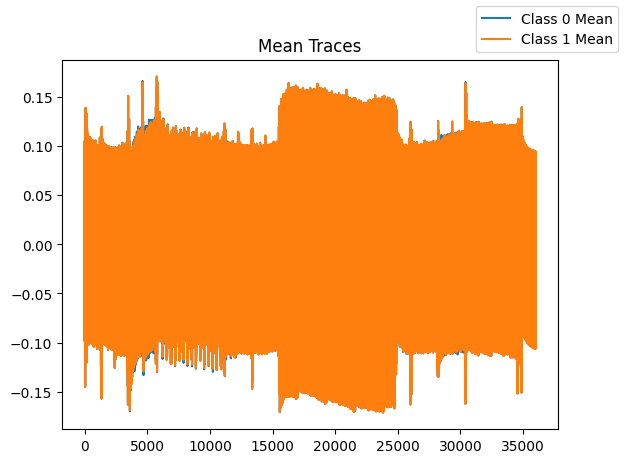

In [ ]:
ttest_analysis_off.plot_means()

In [ ]:
ttest_analysis_off.run_ttest()

Running T-Test: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


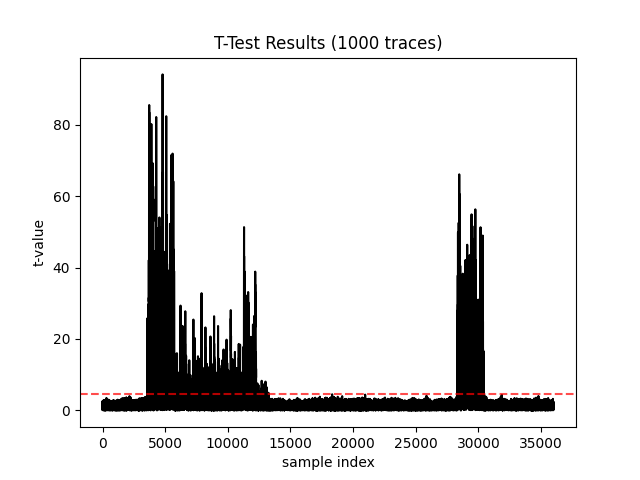

In [ ]:
%matplotlib widget
ttest_analysis_off.plot_ttest()

# PRNG=ON

In [7]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, rand2rand=False)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).


In [ ]:
ttest_analysis_on = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r0_newx2x with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r1_newx2x with 10 traces.
s................: float64



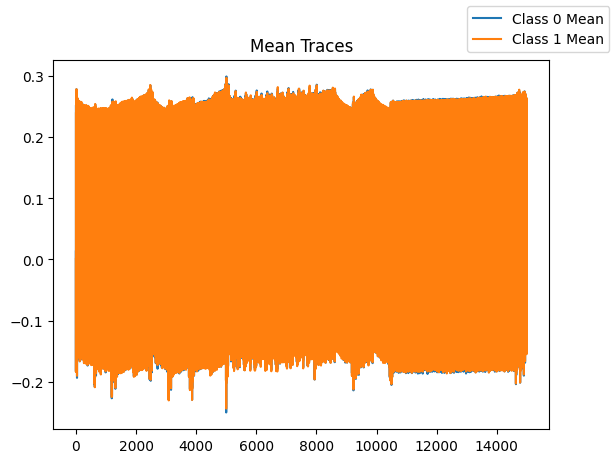

In [ ]:
ttest_analysis_on.plot_means()

In [ ]:
ttest_analysis_on.run_ttest()

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


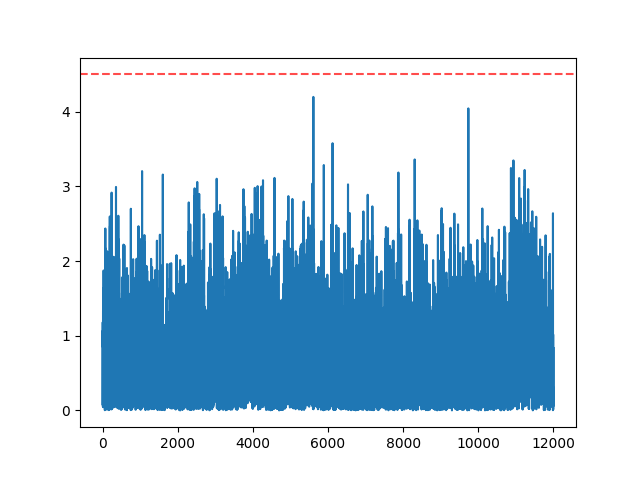

In [ ]:
ttest_analysis_on.plot_ttest(ylimit=10)